# **Analisis data eksploratif**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **Memuat data**

In [ ]:
df = pd.read_csv('advertising.csv')

## **Menampilkan 5 data teratas dan informasi dasar**

In [ ]:
display(df.head())
df.info()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


## **Statistik deskriptif**

In [ ]:
display(df.describe())

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


## **Visualisasi EDA**

In [ ]:
plt.figure(figsize=(15, 5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

## **Pairplot untuk melihat sebaran data**

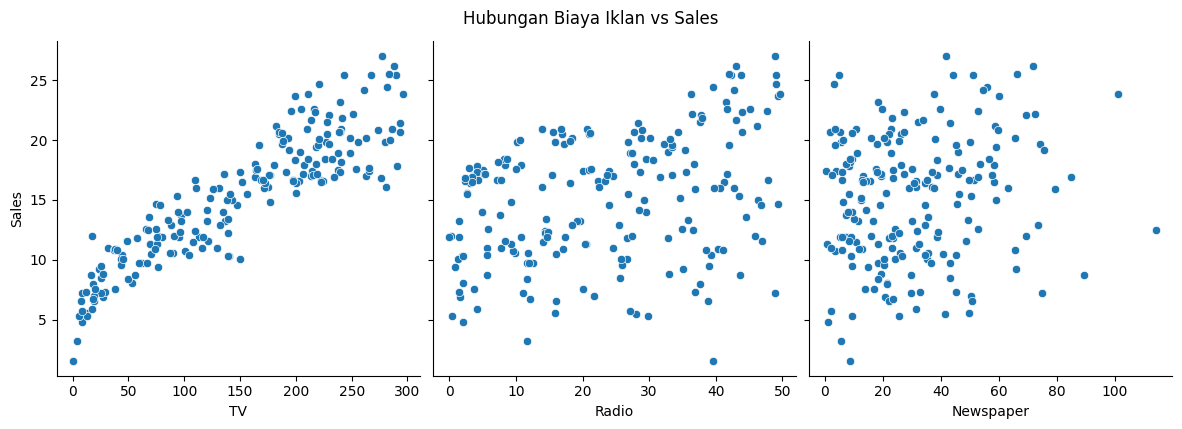

In [ ]:
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=4, aspect=1, kind='scatter')
plt.suptitle("Hubungan Biaya Iklan vs Sales", y=1.05)
plt.show()

## **Heatmap**

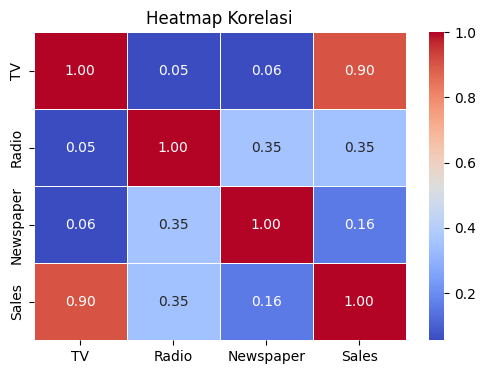

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi")
plt.show()

# **Uji Asumsi**

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

## **Mendefinisikan variabel Independen (X) dan Dependen (y)**

In [ ]:
X = df[['TV', 'Radio', 'Newspaper']]
X_const = sm.add_constant(X)
y = df['Sales']

## **Membuat model dasar untuk diuji**

In [ ]:
model = sm.OLS(y, X_const).fit()
residuals = model.resid

In [ ]:
print(" 1. Uji Multikolinearitas (VIF) ")
vif_data = pd.DataFrame()
vif_data["Fitur"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)
print("Syarat: VIF < 10 berarti aman dari multikolinearitas.\n")

 1. Uji Multikolinearitas (VIF) 
       Fitur       VIF
0         TV  2.486772
1      Radio  3.285462
2  Newspaper  3.055245
Syarat: VIF < 10 berarti aman dari multikolinearitas.



In [ ]:
print(" 2. Uji Normalitas Residu (Shapiro-Wilk) ")
stat, p_value = stats.shapiro(residuals)
print(f"P-value: {p_value:.5f}")
print("Syarat: p-value > 0.05 berarti residu berdistribusi normal.\n")

 2. Uji Normalitas Residu (Shapiro-Wilk) 
P-value: 0.00158
Syarat: p-value > 0.05 berarti residu berdistribusi normal.



In [ ]:
print(" 3. Uji Homoskedastisitas (Breusch-Pagan) ")
bp_test = het_breuschpagan(residuals, model.model.exog)
print(f"P-value: {bp_test[1]:.5f}")
print("Syarat: p-value > 0.05 berarti varians residual konstan (homoskedastisitas).")

 3. Uji Homoskedastisitas (Breusch-Pagan) 
P-value: 0.26379
Syarat: p-value > 0.05 berarti varians residual konstan (homoskedastisitas).


# **Analisis Statistik (Regresi Linear Berganda)**

In [ ]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           8.13e-99
Time:                        13:59:15   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6251      0.308     15.041      0.0

# **Interpretasi hasil**



Berdasarkan model regresi yang dihasilkan dari dataset tersebut, kita dapat menarik kesimpulan:

-Kekuatan Model (R-squared = 0.903): Variabel anggaran periklanan (TV, Radio, Newspaper) secara bersama-sama dapat menjelaskan sekitar 90.3% variasi tingkat Sales. Ini menunjukkan model memiliki daya prediksi yang sangat baik.

-Pengaruh Simultan (Uji F): Nilai p-value (8.13e-99) sangat jauh di bawah tingkat signifikansi 0.05, artinya secara simultan seluruh channel periklanan memengaruhi penjualan secara nyata.

Pengaruh Parsial (Uji t):

-TV: Memiliki koefisien positif dan p-value = 0.000 (< 0.05), menandakan investasi pada iklan TV secara signifikan akan meningkatkan Sales.

-Radio: Memiliki koefisien positif dan p-value = 0.000 (< 0.05), menandakan investasi pada Radio juga berpengaruh positif signifikan terhadap kenaikan Sales.

-Newspaper: Nilai p-value (0.954) lebih besar dari 0.05, artinya iklan koran tidak memberikan efek yang signifikan terhadap penjualan dan merupakan kandidat efisiensi biaya.

Rekomendasi Manajerial: Untuk mengoptimalkan Return on Investment (ROI) dari strategi marketing, disarankan untuk meningkatkan atau mempertahankan proporsi anggaran pada TV dan Radio, sembari mengevaluasi ulang efektivitas atau menghentikan alokasi dana untuk iklan Newspaper.